# Capacitance and Fringing Fields: Student Notebook

Welcome! In this notebook, you will learn how capacitance works in a parallel-plate capacitor and what changes when electric fields fringe at the plate edges.

## Learning Targets

By the end, you should be able to:

- Explain capacitance using charge and voltage.
- Use the parallel-plate model $C = \varepsilon_0\varepsilon_r A/d$.
- Predict how $A$, $d$, and material affect $C$.
- Describe fringing fields and how edge electrons contribute to extra capacitance.
- Compare ideal and fringe-corrected models.

## 1) Core Idea: What is Capacitance?

Capacitance measures how much charge a system stores per volt:

$$C = \frac{Q}{V}$$

For an ideal parallel-plate capacitor:

$$C = \varepsilon_0\varepsilon_r\frac{A}{d}$$

Where:

- $\varepsilon_0$: vacuum permittivity ($8.854\times10^{-12}$ F/m)
- $\varepsilon_r$: relative permittivity of dielectric
- $A$: overlapping plate area
- $d$: plate separation

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Constant
eps0 = 8.854e-12  # F/m

def ideal_capacitance(area_m2, gap_m, eps_r=1.0):
    """Return ideal parallel-plate capacitance in Farads."""
    return eps0 * eps_r * area_m2 / gap_m

In [3]:
# Example capacitor: 10 cm x 10 cm plates, 1 mm gap, air dielectric
A = 0.10 * 0.10      # m^2
d = 1e-3             # m
C = ideal_capacitance(A, d, eps_r=1.0)

print(f"Area = {A:.4f} m^2")
print(f"Gap = {d:.4e} m")
print(f"Capacitance = {C:.3e} F ({C*1e12:.2f} pF)")

Area = 0.0100 m^2
Gap = 1.0000e-03 m
Capacitance = 8.854e-11 F (88.54 pF)


## 2) Explore Parameter Effects

### Predict first
1. If you double area $A$, what happens to $C$?
2. If you double gap $d$, what happens to $C$?
3. If you replace air with a dielectric of $\varepsilon_r=4$, what happens to $C$?

Run the cells below and compare your predictions.

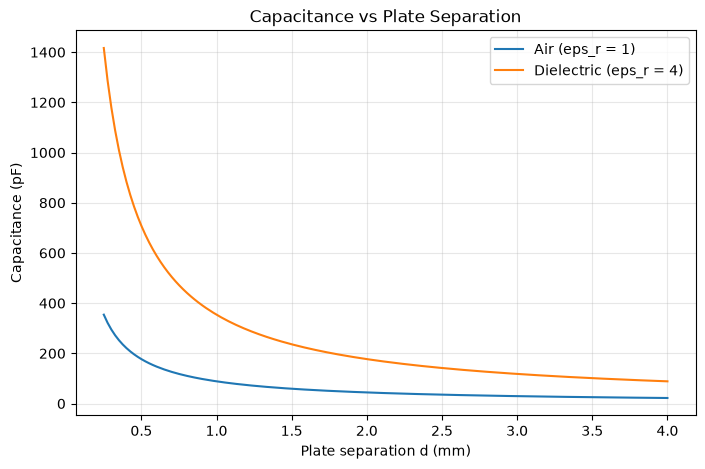

In [4]:
gaps = np.linspace(0.25e-3, 4e-3, 150)
C_air = ideal_capacitance(A, gaps, eps_r=1.0)
C_dielectric = ideal_capacitance(A, gaps, eps_r=4.0)

plt.figure(figsize=(8, 5))
plt.plot(gaps*1e3, C_air*1e12, label='Air (eps_r = 1)')
plt.plot(gaps*1e3, C_dielectric*1e12, label='Dielectric (eps_r = 4)')
plt.xlabel('Plate separation d (mm)')
plt.ylabel('Capacitance (pF)')
plt.title('Capacitance vs Plate Separation')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 3) Fringing Fields and Edge Electrons

The ideal equation assumes all electric field lines are straight and fully between plates.

In real capacitors, near the edges: 

- Field lines bow outward (fringing).
- Electrons at plate edges still contribute to electric field coupling.
- Effective capacitance becomes slightly larger than ideal, especially when gap is not tiny compared to plate width.

A simple engineering correction is:

$$C_{\mathrm{eff}} = C_{\mathrm{ideal}}\left(1 + k\frac{d}{w}\right)$$

where $w$ is a characteristic plate width and $k$ is an empirical constant (often around 0.5 to 1.5 depending on geometry).

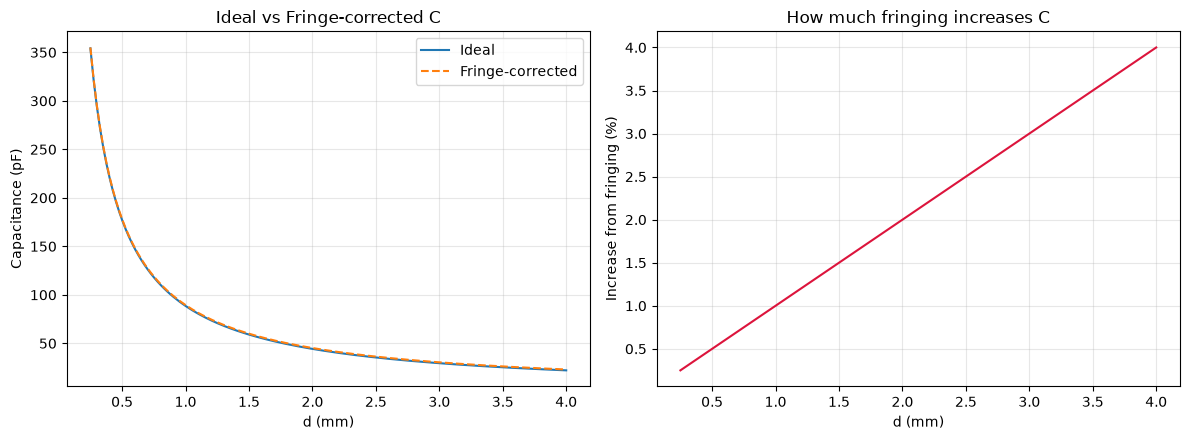

In [5]:
def fringe_corrected_capacitance(area_m2, gap_m, width_m, eps_r=1.0, k=1.0):
    C0 = ideal_capacitance(area_m2, gap_m, eps_r)
    return C0 * (1 + k * gap_m / width_m)

width = 0.10   # m
k = 1.0

C_ideal = ideal_capacitance(A, gaps, eps_r=1.0)
C_fringe = fringe_corrected_capacitance(A, gaps, width, eps_r=1.0, k=k)

percent_increase = (C_fringe - C_ideal) / C_ideal * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(gaps*1e3, C_ideal*1e12, label='Ideal')
ax[0].plot(gaps*1e3, C_fringe*1e12, label='Fringe-corrected', linestyle='--')
ax[0].set_xlabel('d (mm)')
ax[0].set_ylabel('Capacitance (pF)')
ax[0].set_title('Ideal vs Fringe-corrected C')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(gaps*1e3, percent_increase, color='crimson')
ax[1].set_xlabel('d (mm)')
ax[1].set_ylabel('Increase from fringing (%)')
ax[1].set_title('How much fringing increases C')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4) Visualizing the Fringing Pattern (2D Model)

This simple numerical model solves Laplace's equation for two finite plates.

You should observe stronger edge curvature in the electric field arrows near plate ends, which is the fringing effect.

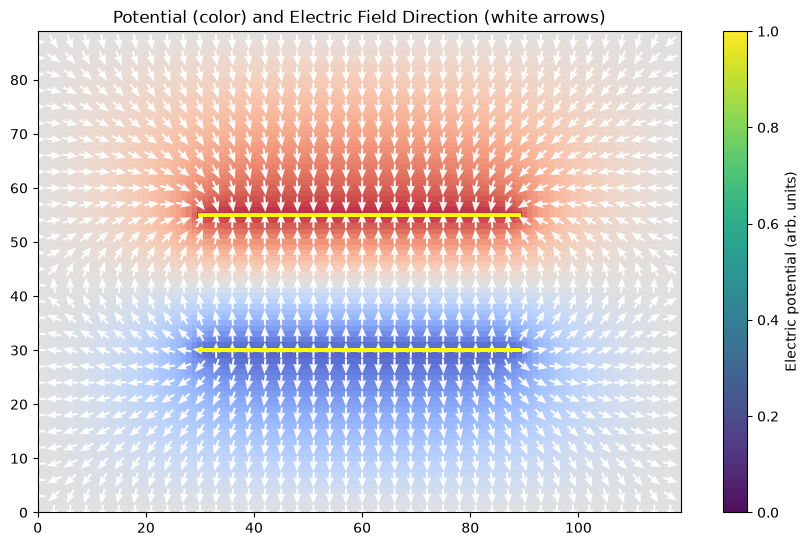

In [6]:
# 2D finite-difference potential solver (simple relaxation)
Nx, Ny = 120, 90
V = np.zeros((Ny, Nx), dtype=float)
mask_fixed = np.zeros_like(V, dtype=bool)

# Plate geometry
x0, x1 = 30, 90
y_top, y_bot = 30, 55

# Set plate potentials
V[y_top, x0:x1] = 1.0
V[y_bot, x0:x1] = -1.0
mask_fixed[y_top, x0:x1] = True
mask_fixed[y_bot, x0:x1] = True

# Boundary at 0 V
mask_fixed[0, :] = True
mask_fixed[-1, :] = True
mask_fixed[:, 0] = True
mask_fixed[:, -1] = True

# Relaxation iterations
for _ in range(1800):
    V_new = V.copy()
    V_new[1:-1, 1:-1] = 0.25 * (
        V[1:-1, 2:] + V[1:-1, :-2] + V[2:, 1:-1] + V[:-2, 1:-1]
    )
    V_new[mask_fixed] = V[mask_fixed]
    V = V_new

# Electric field E = -grad(V)
Ey, Ex = np.gradient(-V)

# Normalize vectors so direction is clearly visible everywhere
mag = np.hypot(Ex, Ey) + 1e-12
Exn, Eyn = Ex / mag, Ey / mag

plt.figure(figsize=(9, 5.5))
# Use reversed colormap so negative is red and positive is blue
plt.imshow(V, origin='lower', cmap='coolwarm_r', alpha=0.88)

step = 3
yy, xx = np.mgrid[0:Ny:step, 0:Nx:step]
plt.quiver(
    xx, yy,
    Exn[::step, ::step], Eyn[::step, ::step],
    color='white', alpha=0.95,
    pivot='mid', scale=42, width=0.0032, headwidth=4.0
 )

# Draw plates in bright yellow so they stand out
plt.plot(np.arange(x0, x1), np.full(x1-x0, y_top), color='yellow', linewidth=3)
plt.plot(np.arange(x0, x1), np.full(x1-x0, y_bot), color='yellow', linewidth=3)

plt.title('Potential (color) and Electric Field Direction (white arrows)')
plt.colorbar(label='Electric potential (arb. units)')
plt.xlim(0, Nx-1)
plt.ylim(0, Ny-1)
plt.tight_layout()
plt.show()

### 4b) One-Plate Fringing (Self-Capacitive Touchscreen Concept)

Great question: many touchscreens use a **single sensing electrode** (self-capacitance) rather than two facing plates.

The return path is through ground/environment. A nearby finger (conductive and effectively grounded) bends field lines and changes the sensed capacitance.

In the visualization below:
- The cyan bar is one sensing electrode at +1 V.
- The yellow circle is a simplified grounded finger at 0 V.
- Background color is potential (red = negative, blue = positive).
- White arrows show electric field direction.

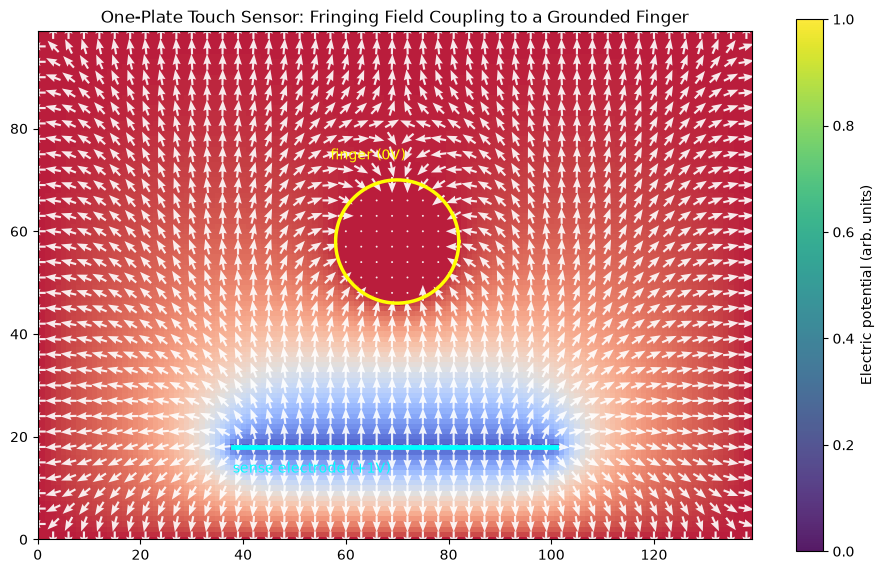

In [7]:
# One-plate self-capacitance model with a grounded "finger"
Nx2, Ny2 = 140, 100
V2 = np.zeros((Ny2, Nx2), dtype=float)
mask2 = np.zeros_like(V2, dtype=bool)

# Outer boundary at 0 V (environment/ground reference)
mask2[0, :] = True
mask2[-1, :] = True
mask2[:, 0] = True
mask2[:, -1] = True

# Single sensing electrode at +1 V
xe0, xe1 = 38, 102
ye = 18
V2[ye, xe0:xe1] = 1.0
mask2[ye, xe0:xe1] = True

# Grounded finger as a circular conductor above electrode
cx, cy, r = 70, 58, 12
yy2, xx2 = np.ogrid[:Ny2, :Nx2]
finger_mask = (xx2 - cx)**2 + (yy2 - cy)**2 <= r**2
V2[finger_mask] = 0.0
mask2[finger_mask] = True

# Relaxation solve for Laplace equation
for _ in range(2400):
    Vn = V2.copy()
    Vn[1:-1, 1:-1] = 0.25 * (
        V2[1:-1, 2:] + V2[1:-1, :-2] + V2[2:, 1:-1] + V2[:-2, 1:-1]
    )
    Vn[mask2] = V2[mask2]
    V2 = Vn

# Electric field from potential
Ey2, Ex2 = np.gradient(-V2)
mag2 = np.hypot(Ex2, Ey2) + 1e-12
Ex2n, Ey2n = Ex2 / mag2, Ey2 / mag2

plt.figure(figsize=(9.5, 5.8))
plt.imshow(V2, origin='lower', cmap='coolwarm_r', alpha=0.9)

step2 = 3
Y2, X2 = np.mgrid[0:Ny2:step2, 0:Nx2:step2]
plt.quiver(
    X2, Y2,
    Ex2n[::step2, ::step2], Ey2n[::step2, ::step2],
    color='white', alpha=0.9,
    pivot='mid', scale=45, width=0.003, headwidth=3.8
)

# Draw electrode and finger outlines
plt.plot(np.arange(xe0, xe1), np.full(xe1 - xe0, ye), color='cyan', linewidth=3.5)
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), color='yellow', linewidth=2.5)

plt.text(xe0, ye - 5, 'sense electrode (+1V)', color='cyan', fontsize=10)
plt.text(cx - 13, cy + r + 4, 'finger (0V)', color='yellow', fontsize=10)

plt.title('One-Plate Touch Sensor: Fringing Field Coupling to a Grounded Finger')
plt.colorbar(label='Electric potential (arb. units)')
plt.xlim(0, Nx2 - 1)
plt.ylim(0, Ny2 - 1)
plt.tight_layout()
plt.show()

### 4c) Interactive Touchscreen Visualization

Use the sliders below to move the finger and change its size in the one-plate touchscreen model.

What to try:
- Move the finger left and right above the electrode.
- Bring the finger closer to the electrode.
- Increase or decrease finger radius.
- Watch how the fringing field pattern changes.

In [8]:
import ipywidgets as widgets
from ipywidgets import interact

def draw_touchscreen_field(cx=70, cy=58, r=12, electrode_voltage=1.0):
    Nx2, Ny2 = 140, 100
    V2 = np.zeros((Ny2, Nx2), dtype=float)
    mask2 = np.zeros_like(V2, dtype=bool)

    # Outer boundary at 0 V (environment / ground reference)
    mask2[0, :] = True
    mask2[-1, :] = True
    mask2[:, 0] = True
    mask2[:, -1] = True

    # Single sensing electrode
    xe0, xe1 = 38, 102
    ye = 18
    V2[ye, xe0:xe1] = electrode_voltage
    mask2[ye, xe0:xe1] = True

    # Grounded finger
    yy2, xx2 = np.ogrid[:Ny2, :Nx2]
    finger_mask = (xx2 - cx)**2 + (yy2 - cy)**2 <= r**2
    V2[finger_mask] = 0.0
    mask2[finger_mask] = True

    # Relaxation solve
    for _ in range(1800):
        Vn = V2.copy()
        Vn[1:-1, 1:-1] = 0.25 * (
            V2[1:-1, 2:] + V2[1:-1, :-2] + V2[2:, 1:-1] + V2[:-2, 1:-1]
        )
        Vn[mask2] = V2[mask2]
        V2 = Vn

    Ey2, Ex2 = np.gradient(-V2)
    mag2 = np.hypot(Ex2, Ey2) + 1e-12
    Ex2n, Ey2n = Ex2 / mag2, Ey2 / mag2

    plt.figure(figsize=(9.5, 5.8))
    plt.imshow(V2, origin='lower', cmap='coolwarm_r', alpha=0.9)

    step2 = 4
    Y2, X2 = np.mgrid[0:Ny2:step2, 0:Nx2:step2]
    plt.quiver(
        X2, Y2,
        Ex2n[::step2, ::step2], Ey2n[::step2, ::step2],
        color='white', alpha=0.9,
        pivot='mid', scale=48, width=0.0028, headwidth=3.8
    )

    plt.plot(np.arange(xe0, xe1), np.full(xe1 - xe0, ye), color='cyan', linewidth=3.5)
    theta = np.linspace(0, 2*np.pi, 200)
    plt.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), color='yellow', linewidth=2.5)

    plt.text(xe0, ye - 5, 'sense electrode', color='cyan', fontsize=10)
    plt.text(cx - r, cy + r + 4, 'finger', color='yellow', fontsize=10)

    plt.title('Interactive One-Plate Touch Sensor Field')
    plt.colorbar(label='Electric potential (arb. units)')
    plt.xlim(0, Nx2 - 1)
    plt.ylim(0, Ny2 - 1)
    plt.tight_layout()
    plt.show()

interact(
    draw_touchscreen_field,
    cx=widgets.IntSlider(min=25, max=115, step=2, value=70, description='finger x'),
    cy=widgets.IntSlider(min=35, max=85, step=2, value=58, description='finger y'),
    r=widgets.IntSlider(min=6, max=18, step=1, value=12, description='radius'),
    electrode_voltage=widgets.FloatSlider(min=0.4, max=1.8, step=0.1, value=1.0, description='plate V'),
);

interactive(children=(IntSlider(value=70, description='finger x', max=115, min=25, step=2), IntSlider(value=58…

## 5) Check Your Understanding

Answer in your own words:

1. Why does increasing plate area increase capacitance?
2. Why does increasing plate separation decrease capacitance?
3. Why are fringing effects larger for small plates or large gaps?
4. How do edge electrons contribute to non-ideal behavior?
5. In which applications might fringing be especially important (sensors, MEMS, touchscreens, etc.)?

## 6) Challenge Extension

Try these modifications:

- Change dielectric constant to model different materials.
- Change plate width and observe how fringe correction changes.
- In the field simulation, shorten plate length and compare edge curvature.
- Estimate when ideal model error exceeds 5%.